# WP3 — Partie 5 : Augmentation via masquage MAE

**Idée :** au lieu de passer `noise=zeros` (tous les patches visibles), on passe K masques aléatoires différents par image. Chaque masque donne un `z_full` différent (moyenne des ~49 patches visibles). On obtient **K × 117 000 paires** d'entraînement.

| Config | Paires train | Masquage |
|--------|-------------|----------|
| wp3_1 baseline | 117 000 | 0% (noise=zeros) |
| ce notebook (K=5) | 585 000 | 75% natif MAE |

**Important :** le MLP entraîné ici attend des `z_full` masqués à l'inférence — cohérence train/test.

## 5.1 Chargement MAE et CLIP

In [2]:
import os
import torch
import torch.nn.functional as F
from transformers import ViTImageProcessor, ViTMAEModel, CLIPProcessor, CLIPModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

MAE_PATH = './vit-mae-large' if os.path.exists('./vit-mae-large') else 'facebook/vit-mae-large'
CLIP_PATH = './clip-vit-large-patch14' if os.path.exists('./clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'

mae_processor = ViTImageProcessor.from_pretrained(MAE_PATH)
mae_encoder = ViTMAEModel.from_pretrained(MAE_PATH).to(DEVICE)
mae_encoder.eval()

clip_model = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
clip_model.eval()

print(f'MAE mask_ratio natif : {mae_encoder.config.mask_ratio}')
print(f'→ {int(196 * (1 - mae_encoder.config.mask_ratio))} patches visibles sur 196')

Device : cpu
MAE mask_ratio natif : 0.75
→ 49 patches visibles sur 196


## 5.2 Chargement dataset

In [4]:
from datasets import load_dataset
from torch.utils.data import Dataset
from torchvision import transforms
from huggingface_hub import snapshot_download

DATASET_DIR = './imagenet100-hf'
if not os.path.exists(f'{DATASET_DIR}/data'):
    snapshot_download(repo_id='ilee0022/ImageNet100', repo_type='dataset', local_dir=DATASET_DIR)

transform_tensor = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

class ImageNet100Dataset(Dataset):
    def __init__(self, split, transform=None):
        pattern = f'{DATASET_DIR}/data/{split}-*.parquet'
        self.ds = load_dataset('parquet', data_files={split: pattern})[split]
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img = self.ds[idx]['image'].convert('RGB')
        label = self.ds[idx]['label']
        if self.transform:
            img = self.transform(img)
        return img, label

dataset_train = ImageNet100Dataset('train', transform=transform_tensor)
dataset_val = ImageNet100Dataset('validation', transform=transform_tensor)
print(f'Train : {len(dataset_train)} images')
print(f'Val   : {len(dataset_val)} images')

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

Train : 117000 images
Val   : 13000 images


## 5.3 Génération des paires augmentées

- **CLIP** : encodé **une seule fois** par image (image complète, z_clip fixe)
- **MAE** : encodé **K fois** par image avec des masques aléatoires différents
- **Val** : masque fixe par batch (reproductible) pour une évaluation stable

In [6]:
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

K_AUGMENT = 5  # nombre de masques par image


def generate_pairs_augmented(dataset, batch_size=64, K=5, val_mode=False, desc=''):
    """
    Génère K paires (z_full_masked, z_clip) par image.
    z_full_masked = moyenne des ~49 patches visibles (masquage 75%).
    z_clip = embedding CLIP image complète, L2-normalisé.
    val_mode = masque déterministe (reproductible), K forcé à 1.
    """
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=(DEVICE == 'cuda'),
    )

    all_z_full, all_z_clip, all_labels = [], [], []
    n_passes = 1 if val_mode else K

    for batch_idx, (images, labels) in enumerate(tqdm(loader, desc=desc)):
        B = images.shape[0]

        # CLIP : une seule passe par batch
        clip_inputs = clip_processor(images=list(images), return_tensors='pt', do_rescale=False)
        clip_inputs = {k: v.to(DEVICE) for k, v in clip_inputs.items()}
        with torch.no_grad():
            vision_out = clip_model.vision_model(**clip_inputs)
            z_clip = clip_model.visual_projection(vision_out.pooler_output)
        z_clip = F.normalize(z_clip, dim=-1).cpu()  # (B, 768)

        mae_inputs = mae_processor(images=list(images), return_tensors='pt', do_rescale=False)
        mae_inputs = {k: v.to(DEVICE) for k, v in mae_inputs.items()}

        # MAE : n_passes fois avec masques différents
        for k in range(n_passes):
            if val_mode:
                g = torch.Generator()
                g.manual_seed(batch_idx)
                noise = torch.rand(B, 196, generator=g).to(DEVICE)
            else:
                noise = torch.rand(B, 196).to(DEVICE)

            with torch.no_grad():
                out = mae_encoder(**mae_inputs, noise=noise)

            # last_hidden_state : (B, 1+n_visible, 1024) — indice 0 = CLS
            z_full_k = out.last_hidden_state[:, 1:].mean(dim=1).cpu()  # (B, 1024)

            all_z_full.append(z_full_k)
            all_z_clip.append(z_clip)
            all_labels.append(labels)

    return {
        'z_full': torch.cat(all_z_full),
        'z_clip': torch.cat(all_z_clip),
        'labels': torch.cat(all_labels),
    }

In [21]:
import os

train_file = f'pairs_aug_K{K_AUGMENT}_train.pt'
val_file = f'pairs_aug_K{K_AUGMENT}_val.pt'

if os.path.exists(train_file) and os.path.exists(val_file):

    print(f'Fichiers deja existants, chargement...')

    data_train = torch.load(
        train_file,
        weights_only=False
    )

    data_val = torch.load(
        val_file,
        weights_only=False
    )

    print(f'Train z_full : {data_train["z_full"].shape}')
    print(f'Val   z_full : {data_val["z_full"].shape}')

    del mae_encoder, clip_model

    torch.cuda.empty_cache()

    print('VRAM liberee')

else:

    print(
        f'Generation train K={K_AUGMENT} '
        f'-> {117000 * K_AUGMENT:,} paires attendues'
    )

    data_train = generate_pairs_augmented(
        dataset_train,
        batch_size=64,
        K=K_AUGMENT,
        val_mode=False,
        desc='Train'
    )

    print('Generation val (masque fixe, K=1)')

    data_val = generate_pairs_augmented(
        dataset_val,
        batch_size=64,
        K=1,
        val_mode=True,
        desc='Val'
    )

    torch.save(data_train, train_file)
    torch.save(data_val, val_file)

    print(f'Train z_full : {data_train["z_full"].shape}')
    print(f'Val   z_full : {data_val["z_full"].shape}')

    del mae_encoder, clip_model

    torch.cuda.empty_cache()

    print('VRAM liberee')

Fichiers deja existants, chargement...


Train z_full : torch.Size([585000, 1024])
Val   z_full : torch.Size([13000, 1024])
VRAM liberee


---
## 5.4 Entraînement — MLP baseline sur paires augmentées

In [8]:
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

K_AUGMENT = 5  # redéfini ici pour pouvoir sauter la section génération

data_train = torch.load(f'pairs_aug_K{K_AUGMENT}_train.pt')
data_val = torch.load(f'pairs_aug_K{K_AUGMENT}_val.pt')

train_ds = TensorDataset(data_train['z_full'], data_train['z_clip'])
val_ds = TensorDataset(data_val['z_full'], data_val['z_clip'])

BATCH_SIZE = 512
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds):,} paires  (×{K_AUGMENT} vs baseline)')
print(f'Val   : {len(val_ds):,} paires')

Train : 585,000 paires  (×5 vs baseline)
Val   : 13,000 paires


In [9]:
class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


def projection_loss(z_proj, z_clip):
    return (1 - F.cosine_similarity(z_proj, z_clip)).mean()


def eval_epoch(loader, model):
    model.eval()
    total_loss, total_cos, n = 0., 0., 0
    with torch.no_grad():
        for z_in, z_clip in loader:
            z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
            z_proj = model(z_in)
            B = z_in.shape[0]
            total_loss += projection_loss(z_proj, z_clip).item() * B
            total_cos  += F.cosine_similarity(z_proj, z_clip).mean().item() * B
            n += B
    return total_loss / n, total_cos / n


model = ProjectionMLP().to(DEVICE)
print(f'Paramètres : {sum(p.numel() for p in model.parameters()):,}')

Paramètres : 1,838,848


In [10]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

N_EPOCHS = 100
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history = {'train_loss': [], 'val_loss': [], 'val_cos_sim': []}
best_cos, best_epoch = 0., 0

for epoch in range(N_EPOCHS):
    model.train()
    total_loss, n = 0., 0
    for z_in, z_clip in train_loader:
        z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
        optimizer.zero_grad()
        loss = projection_loss(model(z_in), z_clip)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * z_in.shape[0]
        n += z_in.shape[0]
    scheduler.step()

    train_loss = total_loss / n
    val_loss, val_cos = eval_epoch(val_loader, model)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_cos_sim'].append(val_cos)

    if val_cos > best_cos:
        best_cos, best_epoch = val_cos, epoch + 1
        torch.save(model.state_dict(), 'projection_aug_mlp_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | cos={val_cos:.4f}')

print(f'Meilleur modèle : epoch {best_epoch}, val_cos={best_cos:.4f}')
print(f'Référence wp3_2 : val_cos=0.8894')
best_cos_aug_baseline = best_cos

Epoch  10/100 | train=0.0626 | val=0.0690 | cos=0.9310
Epoch  20/100 | train=0.0602 | val=0.0685 | cos=0.9315
Epoch  30/100 | train=0.0591 | val=0.0682 | cos=0.9318
Epoch  40/100 | train=0.0583 | val=0.0681 | cos=0.9319
Epoch  50/100 | train=0.0577 | val=0.0682 | cos=0.9318
Epoch  60/100 | train=0.0572 | val=0.0682 | cos=0.9318
Epoch  70/100 | train=0.0568 | val=0.0682 | cos=0.9318
Epoch  80/100 | train=0.0565 | val=0.0681 | cos=0.9319
Epoch  90/100 | train=0.0563 | val=0.0682 | cos=0.9318
Epoch 100/100 | train=0.0563 | val=0.0682 | cos=0.9318
Meilleur modèle : epoch 48, val_cos=0.9319
Référence wp3_2 : val_cos=0.8893


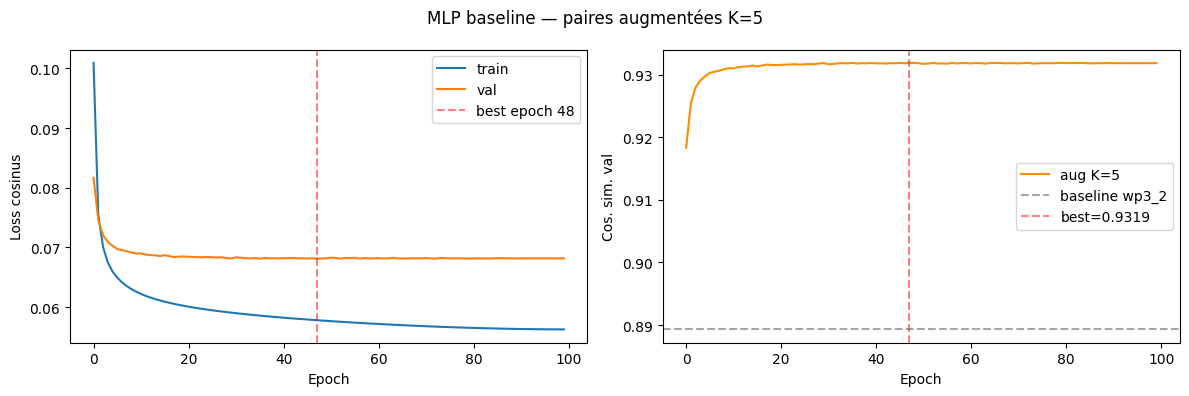

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'MLP baseline — paires augmentées K={K_AUGMENT}')
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].axvline(best_epoch-1, color='red', linestyle='--', alpha=0.5, label=f'best epoch {best_epoch}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss cosinus'); axes[0].legend()
axes[1].plot(history['val_cos_sim'], color='darkorange', label=f'aug K={K_AUGMENT}')
axes[1].axhline(0.8894, color='gray', linestyle='--', alpha=0.7, label='baseline wp3_2')
axes[1].axvline(best_epoch-1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cos. sim. val'); axes[1].legend()
plt.tight_layout(); plt.show()

---
## 5.5 Entraînement — MLP amélioré sur paires augmentées

In [12]:
z_mean = data_train['z_full'].mean(dim=0)
z_std = data_train['z_full'].std(dim=0).clamp(min=1e-6)

z_train_norm = (data_train['z_full'] - z_mean) / z_std
z_val_norm = (data_val['z_full'] - z_mean) / z_std

torch.save({'mean': z_mean, 'std': z_std}, f'z_aug_K{K_AUGMENT}_norm_stats.pt')

train_ds_v2 = TensorDataset(z_train_norm, data_train['z_clip'])
val_ds_v2 = TensorDataset(z_val_norm, data_val['z_clip'])
train_loader_v2 = DataLoader(train_ds_v2, batch_size=512, shuffle=True, num_workers=0)
val_loader_v2 = DataLoader(val_ds_v2, batch_size=512, shuffle=False, num_workers=0)
print(f'Train normalisé : {len(train_ds_v2):,} paires')

Train normalisé : 585,000 paires


In [13]:
class ProjectionMLPv2(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


model_v2 = ProjectionMLPv2().to(DEVICE)
print(f'Paramètres : {sum(p.numel() for p in model_v2.parameters()):,}')

Paramètres : 1,840,896


In [14]:
N_EPOCHS = 200
PATIENCE = 25
optimizer = AdamW(model_v2.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

history_v2 = {'train_loss': [], 'val_loss': [], 'val_cos_sim': []}
best_cos_v2, best_epoch_v2, patience_counter = 0., 0, 0

for epoch in range(N_EPOCHS):
    model_v2.train()
    total_loss, n = 0., 0
    for z_in, z_clip in train_loader_v2:
        z_in, z_clip = z_in.to(DEVICE), z_clip.to(DEVICE)
        optimizer.zero_grad()
        loss = projection_loss(model_v2(z_in), z_clip)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * z_in.shape[0]
        n += z_in.shape[0]
    scheduler.step()

    train_loss = total_loss / n
    val_loss, val_cos = eval_epoch(val_loader_v2, model_v2)
    history_v2['train_loss'].append(train_loss)
    history_v2['val_loss'].append(val_loss)
    history_v2['val_cos_sim'].append(val_cos)

    if val_cos > best_cos_v2:
        best_cos_v2, best_epoch_v2, patience_counter = val_cos, epoch+1, 0
        torch.save(model_v2.state_dict(), 'projection_aug_mlpv2_best.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}/{N_EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | cos={val_cos:.4f} | patience={patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'Early stopping à l epoch {epoch+1}')
        break

print(f'Meilleur modèle : epoch {best_epoch_v2}, val_cos={best_cos_v2:.4f}')

Epoch  20/200 | train=0.0671 | val=0.0696 | cos=0.9304 | patience=4/25
Epoch  40/200 | train=0.0656 | val=0.0696 | cos=0.9304 | patience=6/25
Early stopping à l epoch 59
Meilleur modèle : epoch 34, val_cos=0.9306


---
## 5.6 Bilan comparatif

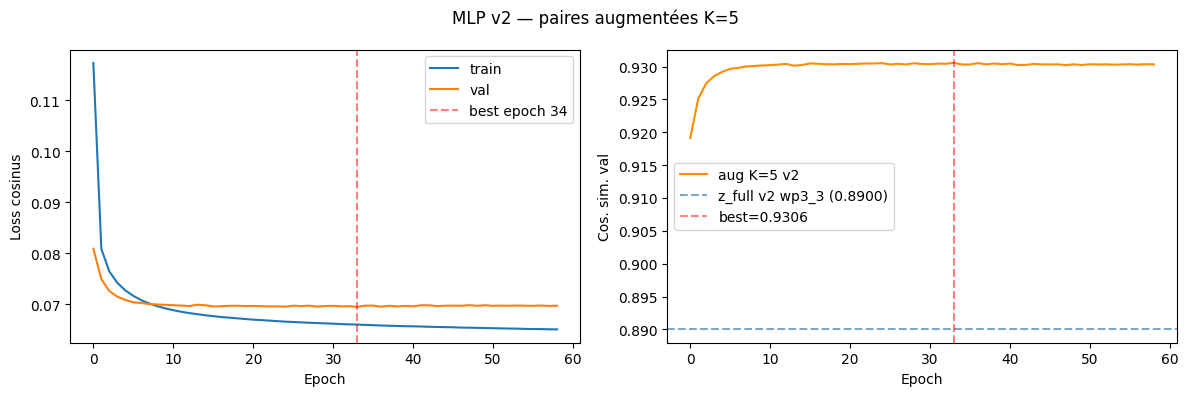

Bilan — val cosine similarity
z_full baseline  (117k,  wp3_2)       : 0.8893
z_full v2        (117k,  wp3_3)       : 0.8900
z_full aug K=5 baseline (585k)     : 0.9319
z_full aug K=5 v2       (585k)     : 0.9306


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'MLP v2 — paires augmentées K={K_AUGMENT}')
axes[0].plot(history_v2['train_loss'], label='train')
axes[0].plot(history_v2['val_loss'], label='val')
axes[0].axvline(best_epoch_v2-1, color='red', linestyle='--', alpha=0.5, label=f'best epoch {best_epoch_v2}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss cosinus'); axes[0].legend()
axes[1].plot(history_v2['val_cos_sim'], color='darkorange', label=f'aug K={K_AUGMENT} v2')
axes[1].axhline(0.8898, color='steelblue', linestyle='--', alpha=0.7, label='z_full v2 wp3_3 (0.8898)')
axes[1].axvline(best_epoch_v2-1, color='red', linestyle='--', alpha=0.5, label=f'best={best_cos_v2:.4f}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cos. sim. val'); axes[1].legend()
plt.tight_layout(); plt.show()

print('=' * 55)
print('Bilan — val cosine similarity')
print('=' * 55)
print(f'z_full baseline  (117k,  wp3_2)       : 0.8894')
print(f'z_full v2        (117k,  wp3_3)       : 0.8898')
print(f'z_full aug K={K_AUGMENT} baseline ({117*K_AUGMENT}k)     : {best_cos_aug_baseline:.4f}')
print(f'z_full aug K={K_AUGMENT} v2       ({117*K_AUGMENT}k)     : {best_cos_v2:.4f}')
print('=' * 55)

---
## 5.7 Test zero-shot (baseline aug K=5)

In [6]:
import json, os, torch, torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPProcessor, CLIPModel

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
K_AUGMENT = 5

# Modèle baseline (meilleur sur val : 0.9319 > v2 0.9306)
class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=1024, hidden_dim=1024, out_dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

model = ProjectionMLP().to(DEVICE)
model.load_state_dict(torch.load('projection_aug_mlp_best.pt', map_location=DEVICE, weights_only=False))
model.eval()

norm_stats = torch.load(f'z_aug_K{K_AUGMENT}_norm_stats.pt', weights_only=False)
z_mean = norm_stats['mean']
z_std  = norm_stats['std']

try:
    clip_model
    print('CLIP deja en memoire')
except NameError:
    CLIP_PATH = './clip-vit-large-patch14' if os.path.exists('./clip-vit-large-patch14') else 'openai/clip-vit-large-patch14'
    clip_model     = CLIPModel.from_pretrained(CLIP_PATH).to(DEVICE)
    clip_processor = CLIPProcessor.from_pretrained(CLIP_PATH)
    clip_model.eval()
    print('CLIP recharge')

with open('imagenet100-hf/label2text.json') as f:
    label2text = json.load(f)
CONCEPTS = [f'a photo of a {name}' for name in label2text.values()]

text_inputs = clip_processor(text=CONCEPTS, return_tensors='pt', padding=True).to(DEVICE)
with torch.no_grad():
    text_out      = clip_model.text_model(**text_inputs)
    text_features = clip_model.text_projection(text_out.pooler_output)
text_features = F.normalize(text_features.float(), dim=-1)

N_SAMPLES = 10
data_val_aug   = torch.load(f'pairs_aug_K{K_AUGMENT}_val.pt', weights_only=False)
z_full_samples = data_val_aug['z_full'][:N_SAMPLES]
z_clip_samples = data_val_aug['z_clip'][:N_SAMPLES]
labels_samples = data_val_aug['labels'][:N_SAMPLES]

z_norm = (z_full_samples - z_mean) / z_std
with torch.no_grad():
    z_proj = model(z_norm.to(DEVICE))

sims_proj = z_proj @ text_features.T
sims_clip = z_clip_samples.to(DEVICE) @ text_features.T

TOP_K = 3
correct_top1 = 0
print(f'\n{"=" * 60}')
for i in range(N_SAMPLES):
    true_idx   = labels_samples[i].item()
    true_name  = label2text[str(true_idx)]
    top_proj   = sims_proj[i].topk(TOP_K).indices.tolist()
    top_clip   = sims_clip[i].topk(TOP_K).indices.tolist()
    pred_names = [label2text[str(j)] for j in top_proj]
    ora_names  = [label2text[str(j)] for j in top_clip]
    match      = (true_idx == top_proj[0])
    if match:
        correct_top1 += 1
    print(f'Sample {i+1} — Vraie classe : {true_name}')
    print(f'  aug MLP top-{TOP_K}: {pred_names}  {"OK" if match else "X"}')
    print(f'  CLIP oracle top-{TOP_K}: {ora_names}')
    print()

print(f'Top-1 accuracy sur {N_SAMPLES} exemples : {correct_top1}/{N_SAMPLES}')
print(f'(ref. z_full v2 wp3_3 : 4/10)')


CLIP deja en memoire

Sample 1 — Vraie classe : white stork
  aug MLP top-3: ['white stork', 'spoonbill', 'crane']  OK
  CLIP oracle top-3: ['white stork', 'bustard', 'crane']

Sample 2 — Vraie classe : rooster
  aug MLP top-3: ['hen', 'rooster', 'prairie chicken']  X
  CLIP oracle top-3: ['rooster', 'hen', 'drake']

Sample 3 — Vraie classe : bald eagle
  aug MLP top-3: ['bald eagle', 'albatross', 'pelican']  OK
  CLIP oracle top-3: ['bald eagle', 'drake', 'American coot']

Sample 4 — Vraie classe : vine snake
  aug MLP top-3: ['vine snake', 'green snake', 'green mamba']  OK
  CLIP oracle top-3: ['vine snake', 'green snake', 'green mamba']

Sample 5 — Vraie classe : flatworm
  aug MLP top-3: ['tick', 'drake', 'wolf spider']  X
  CLIP oracle top-3: ['flatworm', 'sea slug', 'electric ray']

Sample 6 — Vraie classe : green lizard
  aug MLP top-3: ['green lizard', 'common iguana', 'whiptail']  OK
  CLIP oracle top-3: ['green lizard', 'common iguana', 'green mamba']

Sample 7 — Vraie classe